# Severity: Gamma-benchmark for kostnad per registrert egen-skade

## 0. Formål, omfang og låste beslutninger

Målet er en transparent Gamma-benchmark for **registrert skadekostnad per
registrert skade**, og å avgjøre om et lite, forhåndslåst sett av avgrensede
endringer forbedrer en faglig og EDA-forankret baseline.

Styringsdokumentet er [`plans/Severity_plan.md`](plans/Severity_plan.md).
Frekvensfasen ligger i
[`glm_pricing_models.ipynb`](glm_pricing_models.ipynb) og er låst
(`F5_minus-municipality-performance`). Denne notebooken endrer ikke
frekvensmodellen.

**Dette er et låst løp, ikke et søk.** Kandidatrommet, foldene, scoren og
akseptgrensene er bestemt før første modell ble fittet. Et resultat kan ikke
begrunne en ny feature, en ny kategorigrense, en ny splinegrad eller en ny
terskel. Hensikten er å kunne rapportere en ærlig utviklingsscore i stedet for
en score som er optimert frem gjennom mange usynlige valg.

### Brukerbeslutninger som ligger fast

| Beslutning | Innhold |
|---|---|
| CV | Vanlig femfolds gruppe-CV på `insured_id`. Ingen indre CV, ingen ekstra holdout |
| Kandidatrom | Baselinen S0 og de ni utfordrerne under er låst |
| Seter | Bare inndelingen `<5`, `=5`, `>5` |
| Enkelhet | Enklere modeller foretrekkes ved tilnærmet like resultater |
| Storskader | Undersøkes diagnostisk. **Ingen** kapping og **ingen** halemodell i dette løpet |
| Fordeling | Gamma. Inverse Gaussian er eneste mulige utfordrer, og krever egen, uttrykkelig godkjenning før den i det hele tatt implementeres |
| Testår | 2024 røres ikke. Teknisk årssplitt av kildefilen er tillatt; all videre behandling av 2024 er det ikke |

### Hva tallgrensene i notebooken er

1-SE-regelen og 0,5 %-grensen er **konservative beslutningsheuristikker**, ikke
signifikanstester. De brukes flere ganger på de samme valideringsobservasjonene
(enkeltkvalifisering, geografisammenligning, blokkvalg, kombinasjonskontroll,
finalistvalg). Beslutningene er derfor avhengige, de gir ingen kontrollert
samlet feilrate, og de fjerner ikke seleksjonsoptimismen. Det låste
kandidatbudsjettet begrenser søket, men opphever ikke dette forbeholdet.

### Beslutningsregister

Alle valg som påvirker resultatet får en ID (S-xx) og er samlet i seksjon 7.

In [1]:
import re
from functools import partial

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import mean_tweedie_deviance

from src.glm_core import (
    glm_spec,
    prepare_design_frame,
    prepare_fold_frames,
)
from src.model_data import assert_development_years, build_development_frames
from src_severity import severity_descriptives
from src_severity.selection_tests import run_all
from src_severity.severity_cv import (
    build_fold_deviance_table,
    build_score_table,
    compare_pair,
    near_tie_choice,
    qualify_against,
    run_candidates,
)
from src_severity.severity_data import (
    build_severity_inputs,
    summarize_severity_selection,
)
from src_severity.severity_design_checks import (
    check_candidate_fold_design,
    summarize_candidate_design,
)
from src_severity.severity_folds import (
    build_fold_table,
    build_group_folds,
    make_full_population_hook,
)
from src_severity.severity_selection import (
    apply_geography_rule,
    build_selection_table,
    choose_near_tie,
    qualifies,
)

pd.set_option("display.max_columns", 60)

## 1. Datagrunnlag

### 1.1 Sikker utviklingsdataflyt (S-01)

Den tidligere innleseren renset **alle** år før testrammen ble fjernet. For
severity-fasen er flyten lagt om i `src/model_data.py`:

1. Kildefilen leses i biter, og hver bit avgrenses til 2022–2023 **før** noe
   annet skjer. 2024 materialiseres aldri som en ramme, renses aldri og
   transformeres aldri.
2. Hele utviklingspopulasjonen renses **før** produktavgrensning (rensekoden
   forventer en bestemt korreksjonsrad fra 2022).
3. Avgrensning, merke-pooling og transparente prediktorer er uendret fra
   frekvensfasen: `COMP_E`/`COMP_N`, positiv egen-skadepremie, positiv
   eksponering. Kansellerte poliser beholdes.
4. `assert_development_years` er en inngangskontroll som stopper kjøringen
   hvis et annet år enn utviklingsårene når en analysefunksjon.

Radidentitet og rekkefølge er bevart, slik at frekvens- og severity-foldene
kan kobles entydig senere. Kontrolltallene under er de samme som i
frekvensnotebooken, og verifiserer at omleggingen ikke endret populasjonen.

In [2]:
frames = build_development_frames()
development = frames["development"]
assert_development_years(development)  # stopper umiddelbart hvis 2024 skulle nådd hit

assert len(development) == 55_246
assert round(development["total_exposure"].sum(), 2) == 37_126.01
assert development["property_claims"].sum() == 9_989

display(frames["cleaning_log"])
display(
    pd.DataFrame(
        {
            "kontrollpunkt": ["poliseår", "sum eksponering", "registrerte skader"],
            "verdi": [
                len(development),
                round(development["total_exposure"].sum(), 2),
                int(development["property_claims"].sum()),
            ],
        }
    )
)

,step,affected_rows,result
0,"Kontroll av skjema, kategorikoder og unik poli...",0,Bestått
1,Fjerning av omkringliggende mellomrom i tekstfelt,0,Standardisert
2,Ikke-positiv power_to_weight_ratio satt til ma...,1,Standardisert
3,Manglende total- og ansvarseksponering satt ti...,1,Korrigert
4,Rader slettet eller imputert,0,Ingen


,kontrollpunkt,verdi
0,poliseår,55246.00
1,sum eksponering,37126.01
2,registrerte skader,9989.00


### 1.2 Respons, vekt og severity-utvalg (S-02)

Responsen er gjennomsnittlig skadekostnad per registrert skade i poliseåret:

$$
\bar X_i \;=\; \frac{S_i}{N_i},
\qquad
\bar X_i \sim \operatorname{Gamma}(\mu_i,\ \phi/N_i),
\qquad
\log \mu_i \;=\; x_i^{\top}\beta ,
$$

der $S_i$ er `property_incurred` og $N_i$ er `property_claims`. Modellen
estimeres med `var_weights = property_claims`, uten eksponeringsvekt og uten
eksponeringsoffset — severity er betinget på at en skade er registrert, så
eksponeringen er allerede «brukt opp» av frekvensmodellen.

**Utvalget** er poliseår med `property_claims > 0` og samlet
`property_incurred > 0.01`. De utelatte årene har numerisk tilnærmet null
kostnad; de inngår fortsatt i frekvens og i senere ren premie.

**Hva vekten gjør, og hva den forutsetter.** Skadeantallsvekten retter
modellen mot kostnad per registrert skade i aggregatet: et poliseår med fire
skader teller fire ganger så mye som ett med én skade. Det følger av at
gjennomsnittet av $N$ uavhengige Gamma-skader har varians $\mu^2/N$.
Observasjonene er imidlertid fortsatt **poliseår**, ikke rekonstruerte
enkeltskader. Arbeidsantakelsen om varians proporsjonal med $\mu^2/N$ kan
svikte hvis skadene innen samme poliseår er avhengige, og hvordan skadene
telles er ikke dokumentert i datakilden (åpent punkt B-03 fra fase 1).
Dette er en modelleringsantakelse vi bærer videre, ikke et verifisert faktum.

In [3]:
severity_inputs = build_severity_inputs(development)
model_frame = severity_inputs["model_frame"]
severity_frame = severity_inputs["severity_frame"]

# Seter som kategori (S-06): bare inndelingen <5 / =5 / >5, ingen andre grenser.
# Deterministisk transformasjon uten respons, så den kan gjøres én gang her.
for frame in (model_frame, severity_frame):
    frame["seat_category"] = np.select(
        [frame["seats"].lt(5), frame["seats"].eq(5)], ["<5", "=5"], default=">5"
    )

# Kontroll mot plans/Severity_plan.md, "Kontrollert nåsituasjon"
assert len(model_frame) == 55_246
assert len(severity_frame) == 5_698
assert severity_frame["insured_id"].nunique() == 5_323
assert severity_frame["property_claims"].sum() == 9_979

display(summarize_severity_selection(model_frame, severity_frame))

,Poliseår i modellpopulasjonen,Sum eksponering,Sum registrerte skader,Positive skadeår (severity-utvalg),Unike insured_id i severity-utvalget,Sum skader i severity-utvalget,Skadevektet snittseverity (EUR),Utelatte nær-null-poliseår,Registrerte skader i utelatte år
0,55246,37126.013699,9989,5698,5323,9979,872.64457,9,10


## 2. Evalueringsramme, låst før første fit

### 2.1 Primærscore: pooled, skadeantallsvektet Gamma-deviance (S-03)

$$
D \;=\; \frac{\sum_i N_i\, d(y_i, \mu_i)}{\sum_i N_i},
\qquad
d(y, \mu) \;=\; 2\left(\frac{y}{\mu} - 1 - \log\frac{y}{\mu}\right).
$$

Gamma-deviancen er **relativ**: den straffer et 10 %-avvik like hardt ved
500 EUR som ved 50 000 EUR. Det er ønsket for en multiplikativ prismodell,
men det betyr også at små beløp kan få stor vekt i scoren uten å bety noe i
kroner. Det kontrolleres eksplisitt i seksjon 3 og 5.

Foldscorene **pooles med skadeantall**, ikke gjennomsnittsberegnes uvektet.
En uvektet snitt over folder ville gitt folder med færre skader for stor vekt.

### 2.2 Usikkerhet: parvis cluster-SE på `insured_id` (S-04)

Gevinst defineres som $D_{\text{referanse}} - D_{\text{kandidat}}$, altså
positiv når kandidaten er bedre. Standardfeilen beregnes på de vektede
score**forskjellene**, gruppert på `insured_id`, med sentrerte clusterbidrag
og endelig-antall-korreksjon. Parvis sammenligning på de samme radene fjerner
variasjonen som skyldes at foldene er ulike.

Den Poisson-spesifikke hjelpefunksjonen fra frekvensfasen kan ikke brukes
uendret; severity bruker en egen Gamma-variant med samme estimator.

**Hva cluster-SE ikke gjør:** den beskriver usikkerheten i de observerte
scoreforskjellene. Den korrigerer ikke for seleksjonsoptimisme og fanger ikke
hele variasjonen som kommer fra at modellen er trent på nytt i hver fold.

In [4]:
# Primærscoren er sklearns Tweedie-deviance med power=2 — det ER pooled,
# skadeantallsvektet Gamma-deviance (S-03), så ingen egen implementasjon.
GAMMA_FAMILY = sm.families.Gamma(sm.families.links.Log())
GAMMA_POWER = 2
FIT_SETTINGS = {"maxiter": 200, "tol": 1e-8}  # låst likt for alle kandidater (S-07)
pooled_gamma_deviance = partial(mean_tweedie_deviance, power=GAMMA_POWER)

# Referansepunkt før modellering: nullmodellen, dvs. skadevektet snittseverity.
claims = severity_frame["property_claims"]
observed = severity_frame["average_severity"]
null_severity = np.average(observed, weights=claims)
null_deviance = pooled_gamma_deviance(
    observed, np.full(len(severity_frame), null_severity), sample_weight=claims
)
display(
    pd.DataFrame(
        {
            "størrelse": ["skadevektet snittseverity", "nullmodellens deviance D_0"],
            "verdi": [null_severity, null_deviance],
        }
    ).round(4)
)

,størrelse,verdi
0,skadevektet snittseverity,872.6446
1,nullmodellens deviance D_0,0.7698


### 2.3 Fem faste gruppefolder (S-05)

Foldene er de **samme** som i frekvensfasen:
`GroupKFold(n_splits=5, shuffle=True, random_state=100)` på hele
modellpopulasjonens `insured_id`. Severity trenes på foldens positive
skadeår. Begge poliseårene til samme person havner i samme fold, ellers
gjenkjenner modellen personen i valideringen.

Ingen ny seed, ingen omfordeling etter skadekostnad og ingen gjentatt CV for
å lete etter gunstigere resultater.

Modellen predikerer i tillegg **alle poliseår i valideringsfolden**, slik at
den senere frekvens–severity-sammenkoblingen får komplette OOF-prediksjoner.
Selve severity-scoren beregnes bare på det definerte positive utvalget.

In [5]:
cv_folds = build_group_folds(model_frame)
fold_table = build_fold_table(cv_folds, model_frame, severity_frame)

# Planens låste foldstørrelser i severity-utvalget (trening/validering).
EXPECTED_FOLD_SIZES = [
    (4563, 1135),
    (4527, 1171),
    (4593, 1105),
    (4535, 1163),
    (4574, 1124),
]
observed_sizes = list(
    zip(fold_table["skadeår_trening"], fold_table["skadeår_validering"])
)
assert observed_sizes == EXPECTED_FOLD_SIZES, observed_sizes
assert fold_table["personer_overlapp"].eq(0).all()
assert fold_table["skadeår_validering"].sum() == len(severity_frame)

display(fold_table)

,fold,poliseår_trening,poliseår_validering,skadeår_trening,skadeår_validering,skader_validering,personer_validering,personer_overlapp
0,gruppe_1,44187,11059,4563,1135,1960,7461,0
1,gruppe_2,44192,11054,4527,1171,1942,7461,0
2,gruppe_3,44220,11026,4593,1105,1966,7461,0
3,gruppe_4,44240,11006,4535,1163,2056,7461,0
4,gruppe_5,44145,11101,4574,1124,2055,7461,0


### 2.4 Kandidatregister (S-06)

Alle kandidater sammenlignes først mot **samme** faste baseline S0. Ingen
univariat screening, ingen interaksjoner, ingen generell baklengs seleksjon.

| ID | Spesifikasjon | Parametere (med intercept) |
|---|---|---:|
| S0 | Produkt + år + kommunetype + aldersspline df3 + lineær log-bilverdi | 9 |
| A1 | S0 med lineær alder | 7 |
| A2 | S0 med aldersspline df2 | 8 |
| A4 | S0 med aldersspline df4 | 10 |
| V3 | S0 med spline df3 for log-bilverdi | 11 |
| G1 | S0 med kjøresone **i stedet for** kommunetype | 8 |
| G2 | S0 med både kommunetype og kjøresone | 10 |
| P1 | S0 + lineær ytelse | 10 |
| P3 | S0 + ytelsesspline df3 | 12 |
| T1 | S0 + seter kategorisk `<5`, `=5`, `>5` | 11 |

Splines bruker `cr(..., df=k, constraints='center')`. Knuter og sentrering
læres på treningsfolden og gjenbrukes ved prediksjon. Numerisk imputasjon
bruker treningsmedian. Ingen automatisk sletting av rader.

Referansenivåer: produkt `COMP_E`, år 2022, kommune `I`, kjøresone `U`,
seter `=5`.

**Utenfor kandidatrommet:** drivstoff, merke, bilalder, betalingsfrekvens,
`business_type` og kjøreerfaring. Tidligere lekkasjeeksklusjoner videreføres.

Baselinen er **faglig og EDA-forankret, med begrenset direkte kaskolitteratur**.
Den er ikke uavhengig av tidligere innsikt fra de samme utviklingsårene.
Gamma med log-link har etablert metodisk støtte for severity
([CAS Monograph 5](https://www.casact.org/sites/default/files/database/monographs_papers_05-goldburd-khare-tevet.pdf)),
men det begrunner en startmodell — ikke at fordelingen beskriver disse dataene
korrekt.

In [6]:
# Låste referansenivåer (S-06). For `year` avviker planens 2022 fra B-24-regelen
# (nivået med størst eksponering er 2023). Referansenivået endrer verken
# tilpasningen eller deviancen, bare hvilke koeffisienter som rapporteres.
BASE_LEVELS = {
    "policy_type": "COMP_E",
    "year": 2022,
    "municipality_type": "I",
    "circulation_area": "U",
    "seat_category": "=5",
}


def spline(column, df):
    """Sentrert naturlig kubisk spline (B-10). Sentrering er obligatorisk."""
    return f"cr({column}, df={df}, constraints='center')"


S0_TERMS = [
    "policy_type",
    "year",
    "municipality_type",
    spline("driver_age", 3),
    "log_vehicle_value",
]
AGE_POSITION, GEO_POSITION = 3, 2

CANDIDATE_TERMS = {
    "S0": S0_TERMS,
    "A1": [*S0_TERMS[:AGE_POSITION], "driver_age", *S0_TERMS[AGE_POSITION + 1 :]],
    "A2": [
        *S0_TERMS[:AGE_POSITION],
        spline("driver_age", 2),
        *S0_TERMS[AGE_POSITION + 1 :],
    ],
    "A4": [
        *S0_TERMS[:AGE_POSITION],
        spline("driver_age", 4),
        *S0_TERMS[AGE_POSITION + 1 :],
    ],
    "V3": [*S0_TERMS[:-1], spline("log_vehicle_value", 3)],
    "G1": [*S0_TERMS[:GEO_POSITION], "circulation_area", *S0_TERMS[GEO_POSITION + 1 :]],
    "G2": [*S0_TERMS, "circulation_area"],
    "P1": [*S0_TERMS, "performance_hp_per_tonne"],
    "P3": [*S0_TERMS, spline("performance_hp_per_tonne", 3)],
    "T1": [*S0_TERMS, "seat_category"],
}

In [7]:
def raw_columns(terms):
    """Råkolonnene bak formelleddene; `cr(x, ...)` bidrar med kolonnen `x`."""
    return [
        re.match(r"cr\((\w+)", term)[1] if term.startswith("cr(") else term
        for term in terms
    ]


severity_specs = {
    name: glm_spec(
        name,
        terms,
        "average_severity",
        severity_frame,
        GAMMA_FAMILY,
        "property_claims",
        GAMMA_POWER,
        required_columns=raw_columns(terms),
        base_level_overrides=BASE_LEVELS,
    )
    for name, terms in CANDIDATE_TERMS.items()
}

# Planens låste parametertall (med intercept). Kontrolleres mot de faktiske
# designmatrisene i 3.5 — de endres aldri for å få en kandidat til å passe.
PLAN_PARAMETERS = {
    "S0": 9,
    "A1": 7,
    "A2": 8,
    "A4": 10,
    "V3": 11,
    "G1": 8,
    "G2": 10,
    "P1": 10,
    "P3": 12,
    "T1": 11,
}
display(
    pd.DataFrame(
        {
            "ID": list(severity_specs),
            "formel": [s["formula"] for s in severity_specs.values()],
            "parametere (plan)": [PLAN_PARAMETERS[k] for k in severity_specs],
        }
    )
)

,ID,formel,parametere (plan)
0,S0,"average_severity ~ C(policy_type, Treatment('C...",9
1,A1,"average_severity ~ C(policy_type, Treatment('C...",7
2,A2,"average_severity ~ C(policy_type, Treatment('C...",8
3,A4,"average_severity ~ C(policy_type, Treatment('C...",10
4,V3,"average_severity ~ C(policy_type, Treatment('C...",11
5,G1,"average_severity ~ C(policy_type, Treatment('C...",8
6,G2,"average_severity ~ C(policy_type, Treatment('C...",10
7,P1,"average_severity ~ C(policy_type, Treatment('C...",10
8,P3,"average_severity ~ C(policy_type, Treatment('C...",12
9,T1,"average_severity ~ C(policy_type, Treatment('C...",11


### 2.5 Gyldighet før seleksjon (S-07)

En kandidat må bestå i **alle fem folder**:

- Minst 50 unike `insured_id` i hvert kategorinivå i severity-**treningen**.
- Full rang, ingen uventet radbortfall, endelige parametere og positive,
  endelige prediksjoner.
- Konvergens med samme innstillinger for alle kandidater: maksimalt 200
  iterasjoner, toleranse `1e-8`.
- Ingen usette kategorinivåer ved prediksjon, ingen manglende verdier etter
  preprocessing.

En kandidat som ikke består, markeres ugyldig og forkastes. **Ingen** ny
pooling, kategorisering eller regularisering legges til som redningsforsøk.
Svikt i S0 stopper hele seleksjonsløpet.

50-personerskravet gjelder **treningsstøtte**. Det innføres ingen minstegrense
per valideringskategori: små valideringssegmenter beholder observasjonene sine
i pooled score, men merkes som svakt støttet og kan ikke alene begrunne en
segmentkonklusjon.

### 2.6 Utvalgsregler (S-08)

**Forbedringsregel** (kandidat med like mange eller flere parametere):

$$
D_{\text{ref}} - D_{\text{kand}} \;>\; \max\!\left(\mathrm{SE}_{\text{par}},\; 0{,}005 \cdot D_{\text{ref}}\right)
\quad\text{og forbedring i minst 4 av 5 folder.}
$$

**Forenklingsregel** (kandidat med færre parametere):

$$
D_{\text{kand}} - D_{\text{ref}} \;\le\; \min\!\left(\mathrm{SE}_{\text{par}},\; 0{,}005 \cdot D_{\text{ref}}\right).
$$

En forenkling kan altså aksepteres med et lite tap, men bare innenfor
**begge** grensene.

**Asymmetrien er tilsiktet.** Forbedringsregelen krever 4 av 5 folder;
forenklingsregelen krever ikke et bestemt antall forbedrede folder. Det
uttrykker den avtalte preferansen for enkelhet — ikke en påstand om at
forenklingen er bedre i hver fold. Foldvise forskjeller vises uansett, også
når pooled score kvalifiserer en forenkling som taper i flere folder.

**Regel for nesten like resultater:** finn laveste score blant kvalifiserte
kandidater; ta med alternativer innenfor **både** én parvis SE og 0,5 % av den
beste scoren; velg færrest parametere, deretter lavest score, deretter
alfabetisk ID.

### 2.7 Seleksjonsalgoritmen, utført én gang (S-09)

1. Kvalifiser alle ni enkeltutfordrere mot S0.
2. **Geografisærregelen:** G2 må bestå forbedringsregelen mot **både** S0 og
   G1, på de samme fem foldene. G1 må være gyldig, men trenger ikke selv å
   kvalifisere mot S0 for å være sammenligningsgrunnlag. Er G1 ugyldig, kan
   tilleggsverdien ikke dokumenteres, og G2 kvalifiserer ikke. En gevinst mot
   G1 kan aldri kompensere for at G2 ikke består kravet mot S0.
3. Velg ett alternativ i hver blokk (alder, verdi, geografi, ytelse, seter)
   med regelen for nesten like resultater. S0 representerer uendret blokk.
4. Endres minst to blokker, bygg **én** samlet kandidat C1. Ingen andre
   kombinasjoner tillates.
5. C1 må bestå den relevante regelen mot S0 **og** mot hver valgt
   enkeltutfordrer, ut fra parametertallet i hvert sammenligningspar.
6. Velg finalist blant S0, kvalifiserte enkeltutfordrere og eventuell
   kvalifisert C1, med samme regel for nesten like resultater.
7. Forkastes C1, brukes de allerede kvalifiserte enkeltmodellene. Ingen
   oppdeling av C1 og ingen ny kombinasjonsrunde.

**Budsjett:** høyst ti faste spesifikasjoner og én kombinert kandidat, altså
maksimalt 55 hovedtilpasninger over fem folder. Diagnostiske refittinger føres
separat og kan ikke bli nye kandidater. Søket er avsluttet også når
konklusjonen blir at S0 beholdes.

In [8]:
# Seleksjonsreglene (forbedring, forenkling, nesten-like, geografi) er ren
# logikk i src_severity/severity_selection.py, dekket av syntetiske tester i
# src_severity/selection_tests.py: grenseulikhetene (streng ved forbedring,
# ikke-streng ved forenkling), foldkravet, hvilken av SE- og 0,5%-komponenten
# som binder, tie-break-rekkefølgen og geografisærregelen.
n_passed, n_failed = run_all()
print(f"Seleksjonsregler: {n_passed} syntetiske tester bestått, {n_failed} feilet.")
assert n_failed == 0, "Reglene feiler egne tester — stopp før kandidatfitting."

[OK] Forbedring: gevinst nøyaktig på terskelen kvalifiserer ikke (streng ulikhet)
[OK] Forbedring: gevinst over terskel men bare 3/5 folder kvalifiserer ikke
[OK] Forbedring: gevinst over terskel og 4/5 folder kvalifiserer
[OK] Forbedring: SE_par bindende når SE > 0,5%-grensen
[OK] Forbedring: 0,5%-grensen bindende når den er større enn SE_par
[OK] Forenkling: SE_par bindende når SE < 0,5%-grensen
[OK] Forenkling: 0,5%-grensen bindende når den er mindre enn SE_par
[OK] Forenkling: lite tap innenfor begge grenser kvalifiserer
[OK] Forenkling: tap innenfor bare én grense kvalifiserer ikke
[OK] Forenkling: tap nøyaktig lik terskelen kvalifiserer (ikke-streng ulikhet)
[OK] Nesten-like: innenfor SE men utenfor 0,5% er IKKE nesten lik
[OK] Nesten-like: innenfor 0,5% men utenfor SE er IKKE nesten lik
[OK] Nesten-like: færrest parametere slår lavest score
[OK] Nesten-like: likt parametertall -> lavest score vinner
[OK] Nesten-like: likt parametertall og score -> alfabetisk ID vinner
[OK] Neste

## 3. Diagnostikk før fitting

Ingen av diagnostikkene i denne seksjonen åpner for nye features eller nye
terskler i kandidatsøket. De skal avdekke datafeil og målkonflikter **før**
modellene kjøres.

### 3.1 Kostnadskonsentrasjon og storskader

Hvor mye av severity-utvalgets kostnad kommer fra de dyreste poliseårene og
personene, og hvor mange skadeår som ligger over grovkalibrerte
storskadeterskler (5 000 / 7 500 / 10 000 EUR)? Formålet er å se om noen få
observasjoner kan dominere Gamma-deviancen — ikke å åpne for kapping eller
nye terskler i kandidatsøket.

In [9]:
cost_concentration_table = severity_descriptives.build_cost_concentration_table(
    severity_frame
)
display(cost_concentration_table.round(4))

,grunnlag,type,nivå,antall_enheter,beløp,andel
0,poliseår,andel_topp,topp 0.1%,6,1.381311e+05,0.0159
1,poliseår,andel_topp,topp 1%,57,7.431288e+05,0.0853
2,poliseår,andel_topp,topp 5%,285,2.053141e+06,0.2358
3,poliseår,andel_topp,topp 10%,570,3.083679e+06,0.3541
4,poliseår,topp_bidrag,#1,1,2.733254e+04,0.0031
5,poliseår,topp_bidrag,#2,1,2.412070e+04,0.0028
6,poliseår,topp_bidrag,#3,1,2.319734e+04,0.0027
7,poliseår,topp_bidrag,#4,1,2.311316e+04,0.0027
8,poliseår,topp_bidrag,#5,1,2.104758e+04,0.0024
9,person,andel_topp,topp 0.1%,6,1.451336e+05,0.0167


In [10]:
large_claim_table = severity_descriptives.build_large_claim_table(severity_frame)
display(large_claim_table.round(4))

# Kontroll mot plans/Severity_plan.md: 136/68/37 skadeår over de tre
# tersklene, på grunnlaget gjennomsnittsskade.
n_over_thresholds = large_claim_table.loc[
    large_claim_table["grunnlag"].eq("gjennomsnittsskade"), "antall_skadeår"
].tolist()
assert n_over_thresholds == [136, 68, 37], n_over_thresholds

,terskel,grunnlag,antall_skadeår,unike_personer,kostnadsandel,overskytende_kostnadsandel
0,5000,samlet årskostnad,200,192,0.1906,0.0757
1,5000,gjennomsnittsskade,136,134,0.1423,0.0613
2,7500,samlet årskostnad,85,84,0.1110,0.0378
3,7500,gjennomsnittsskade,68,67,0.0913,0.0318
4,10000,samlet årskostnad,44,44,0.0714,0.0209
5,10000,gjennomsnittsskade,37,37,0.0613,0.0176


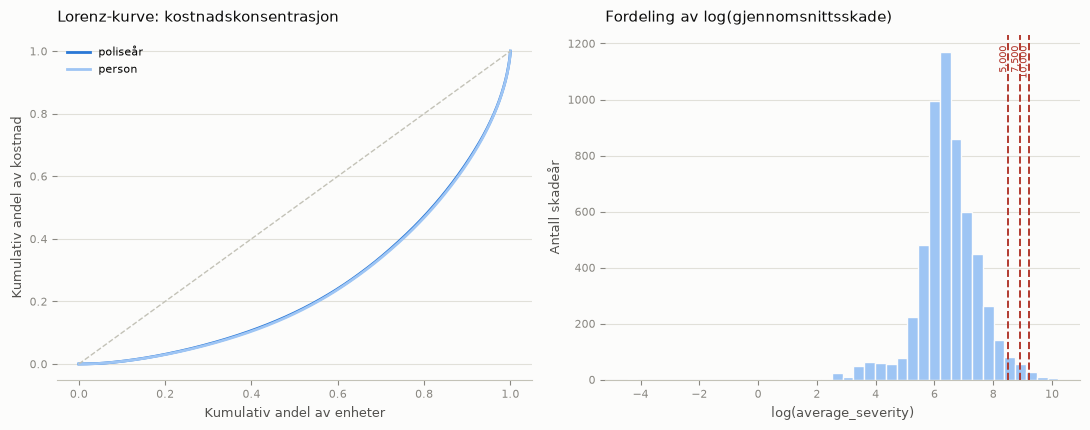

In [11]:
display(severity_descriptives.plot_cost_concentration(severity_frame))

**Konklusjon 3.1.** Kostnaden er skjev, men ikke dominert av enkeltobservasjoner:
de dyreste 1 % av skadeårene står for 8,5 % av kostnaden og de dyreste 10 % for
35,4 %, mens det dyreste enkeltåret (27 332 EUR) utgjør 0,31 %. Person- og
poliseårsnivå gir nesten identiske tall, som forventet når 5 698 skadeår fordeler
seg på 5 323 personer — konsentrasjonen skyldes dyre år, ikke personer med mange
skadeår. Av de 136 skadeårene over 5 000 EUR i gjennomsnittsskade ligger bare
6,1 % av totalkostnaden *over* selve terskelen. Vi kapper derfor ingenting: det
finnes ingen naturlig storskadegrense her, og Gamma-deviancen er uansett relativ,
slik at et dyrt år ikke automatisk dominerer scoren.

### 3.2 Små beløp og deviancens relative natur

Gamma-deviancen er relativ: et 10 %-avvik straffes like hardt ved 500 EUR
som ved 50 000 EUR, så små beløp kan i prinsippet drive scoren uten å bety
noe i kroner. Vi ser derfor på skadeår med svært lav gjennomsnittsskade,
de utelatte nær-null-årene, og eksakte beløpsklumper (mulige forhåndsavtalte
oppgjørsbeløp).

In [12]:
small_amount_tables = severity_descriptives.build_small_amount_table(
    severity_frame, model_frame
)
display(small_amount_tables["små_terskler"].round(4))
display(small_amount_tables["utelatte_nullår"])
display(small_amount_tables["beløpsklumper"].round(4))

,terskel,antall_skadeår,skadeantall,kostnadsandel
0,1,1,1,0.0
1,10,3,3,0.0


,antall_utelatte_poliseår,sum_registrerte_skader
0,9,10


,property_incurred,antall_skadeår,andel_skadeår
0,16.1115,21,0.0037
1,36.1790,6,0.0011
2,48.7025,5,0.0009
3,45.9195,4,0.0007
4,33.3960,4,0.0007
5,19.1935,3,0.0005
6,41.7450,3,0.0005
7,644.6555,3,0.0005
8,47.3110,3,0.0005
9,1085.2205,3,0.0005


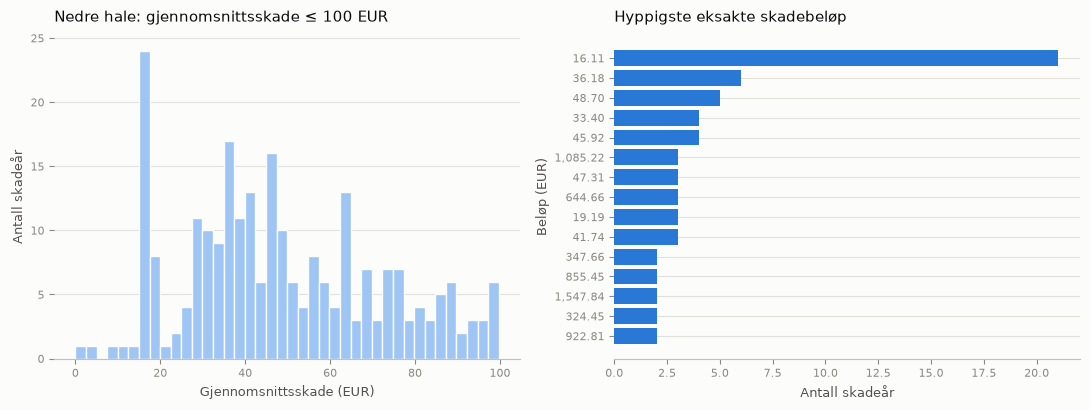

In [13]:
display(severity_descriptives.plot_small_amounts(severity_frame))

**Konklusjon 3.2.** Utelatelsesregelen (B-15) er praktisk talt kostnadsfri: bare
9 poliseår med til sammen 10 registrerte skader faller ut, altså 0,02 % av
modellpopulasjonen og 0,1 % av skadene. Det reelle forbeholdet ligger et annet
sted: beløpene klumper seg på eksakte verdier — 21 skadeår ligger på nøyaktig
16,11 EUR, og flere beløp (644,66, 1 085,22, 1 547,84 EUR) går igjen identisk.
Dette ser ut som faste oppgjørs- eller administrasjonsbeløp snarere enn
modellerbar skadekostnad. Siden Gamma-deviancen er relativ, teller et avvik på
16 EUR like mye per skade som et avvik på 16 000 EUR. Antallet er lite (~1 % av
radene), så virkningen på seleksjonen er begrenset, men dette føres som en
fortolkningsbegrensning — ikke som grunnlag for en ny filtreringsregel.

### 3.3 Kategoristøtte

Antall unike `insured_id` per nivå i hver kategoriske prediktor i
kandidatrommet (produkt, år, kommunetype, kjøresone, setekategori og
skadeantallsgruppe), slik at 50-personerskravet i S-07 kan vurderes før
første kandidatfit.

In [14]:
support_table = severity_descriptives.build_support_table(severity_frame)
display(support_table.round(4))

,variabel,nivå,antall_skadeår,unike_personer,skadeantall,kostnadsandel,skadevektet_severity,svakt_støttet
0,policy_type,COMP_E,3961,3744,5615,0.6591,1022.1694,False
1,policy_type,COMP_N,1737,1585,4364,0.3409,680.2564,False
2,year,2022,1722,1722,2822,0.3045,939.7782,False
3,year,2023,3976,3976,7157,0.6955,846.1738,False
4,municipality_type,C,1462,1357,2498,0.2631,917.3418,False
5,municipality_type,I,4034,3772,7179,0.7065,856.9800,False
6,municipality_type,IS,202,195,302,0.0304,875.3019,False
7,circulation_area,R,1966,1852,3219,0.3552,960.8148,False
8,circulation_area,U,3732,3471,6760,0.6448,830.6594,False
9,setekategori,<5,334,313,623,0.0608,849.2435,False


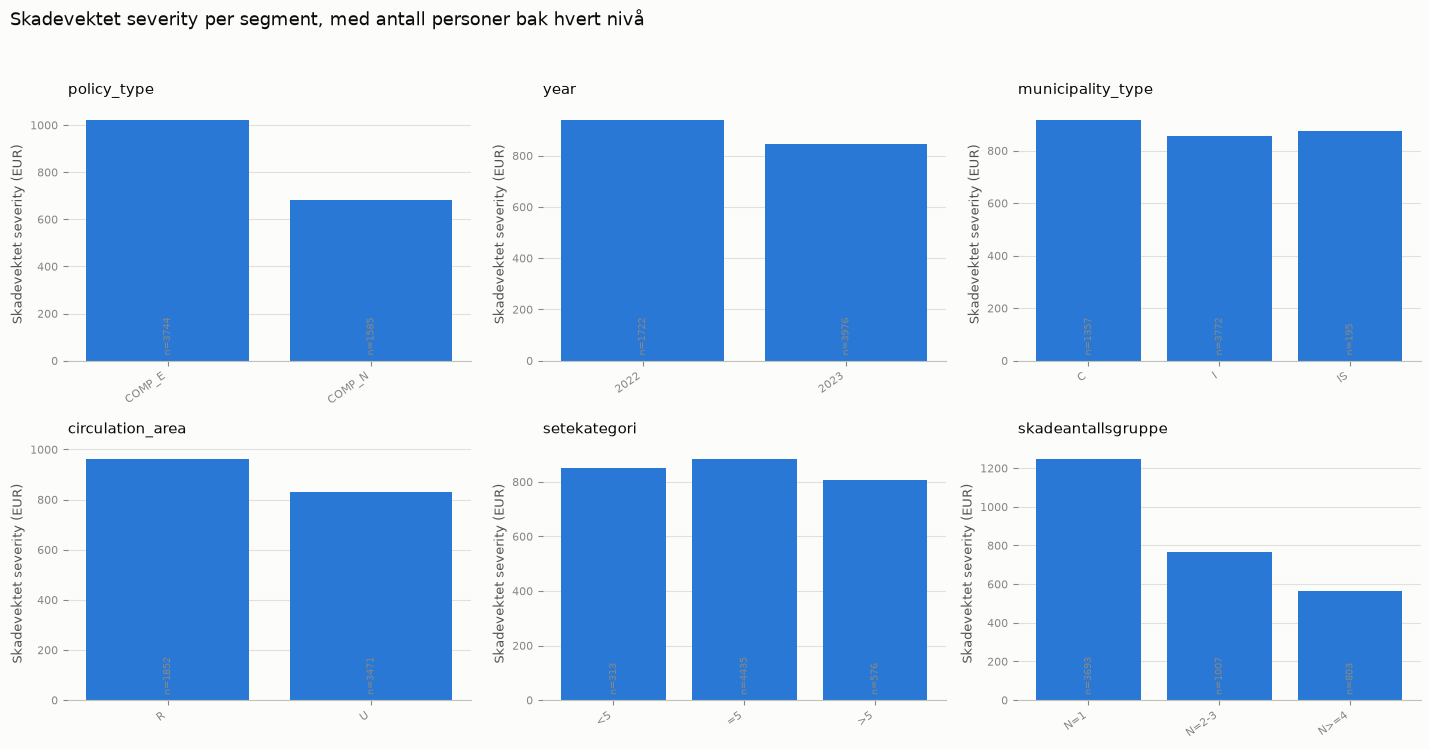

In [15]:
display(severity_descriptives.plot_support(severity_frame))

**Konklusjon 3.3.** Ingen nivåer er svakt støttet. Det minste nivået i hele
severity-utvalget er `municipality_type = "IS"` med 195 unike personer — godt over
50-personerskravet i S-07. Kandidatrommet kan dermed kjøres slik det er låst,
uten sammenslåing av nivåer.

### 3.4 Foldvis kontroll av designmatrisene (S-10)

Før første kandidatfit bygges designmatrisene foldvis, og kategorinivåer,
referansenivåer, kolonneantall og rang kontrolleres mot kandidatregisteret.
Avvik håndteres etter gyldighetsreglene — implementeringen skal **ikke** stille
endre parametertall eller utelate nivåer for å få en kandidat til å passe.

In [16]:
design_checks = check_candidate_fold_design(
    severity_specs, severity_frame, cv_folds, prepare_fold_frames, prepare_design_frame
)
design_summary = summarize_candidate_design(design_checks)
display(design_summary)

# Planens låste parametertall skal stemme eksakt — ingen justering ved avvik.
observed_columns = design_summary.set_index("kandidat")["kolonner"].to_dict()
for candidate, expected in PLAN_PARAMETERS.items():
    assert observed_columns[candidate] == expected, (
        candidate,
        observed_columns[candidate],
        expected,
    )

,kandidat,kolonner,min_rang,min_kategoristøtte,alle_folder_full_rang,alle_folder_støtte_ok,antall_avviste_folder
0,S0,9,9,145,True,True,0
1,A1,7,7,145,True,True,0
2,A2,8,8,145,True,True,0
3,A4,10,10,145,True,True,0
4,V3,11,11,145,True,True,0
5,G1,8,8,1239,True,True,0
6,G2,10,10,145,True,True,0
7,P1,10,10,145,True,True,0
8,P3,12,12,145,True,True,0
9,T1,11,11,145,True,True,0


**Konklusjon 3.4.** Alle ti kandidater treffer planens parametertall eksakt
(9/7/8/10/11/8/10/10/12/11 kolonner inkludert intercept), har full rang i alle
fem folder, og ingen fold avvises på grunn av kategorinivåer som mangler i
treningsdelen. Den minste kategoristøtten innenfor en treningsfold er 145 unike
personer (`municipality_type = "IS"`); G1 har 1 239 fordi den ikke bruker
`municipality_type` i det hele tatt. Gyldighetsporten S-07/S-10 er dermed
passert **før** første fit, og alle ti kandidatene går inn i det låste løpet.

## 4. Låst Gamma-løp

Seleksjonsalgoritmen (S-09) kjøres nå én gang. Resultatene fra alle kandidater
lagres, også de forkastede, og søket avsluttes etter algoritmen — også dersom
konklusjonen blir at S0 beholdes. Budsjettet er ti faste spesifikasjoner pluss
høyst én kombinert kandidat, altså maksimalt 55 hovedtilpasninger.

### 4.1 Kjøring av de ti spesifikasjonene

In [17]:
# Hver kandidat kjøres én gang over de fem låste foldene. fold_hook lagrer i
# tillegg prediksjoner for hele modellpopulasjonen (S-11), til bruk i seksjon 5.
full_population_hook = make_full_population_hook(model_frame, severity_frame, cv_folds)
severity_results, fits_used = run_candidates(
    severity_specs, severity_frame, cv_folds, FIT_SETTINGS, fold_hook=full_population_hook
)
print(f"hovedtilpasninger brukt: {fits_used} av budsjettet 55")

hovedtilpasninger brukt: 50 av budsjettet 55


In [18]:
score_table = build_score_table(severity_results, severity_frame, PLAN_PARAMETERS)
display(score_table.round(6))

# Gyldighetskravene i S-07: konvergens i alle folder og OOF-prediksjon på alle
# 5 698 skadeårene. Kandidater som faller her, kan ikke sammenlignes videre.
valid_candidates = set(score_table.loc[score_table["gyldig"], "ID"])
assert valid_candidates, "ingen gyldige kandidater"

,ID,parametere,parametere_plan,pooled_deviance,fold_min,fold_maks,rader_oof,alle_konvergerte,gyldig,feil
0,G1,8,8,0.725493,0.664128,0.764725,5698,True,True,None
1,T1,11,11,0.727654,0.668645,0.766923,5698,True,True,None
2,G2,10,10,0.727852,0.663593,0.765453,5698,True,True,None
3,A1,7,7,0.728269,0.668283,0.764626,5698,True,True,None
4,A2,8,8,0.728461,0.668281,0.764669,5698,True,True,None
5,A4,10,10,0.728467,0.667956,0.767092,5698,True,True,None
6,S0,9,9,0.729006,0.668240,0.766679,5698,True,True,None
7,V3,11,11,0.729605,0.668305,0.767299,5698,True,True,None
8,P1,10,10,0.729694,0.667104,0.768461,5698,True,True,None
9,P3,12,12,0.730374,0.667764,0.770581,5698,True,True,None


In [19]:
fold_deviance_table = build_fold_deviance_table(severity_results)
display(fold_deviance_table.round(6))

,S0,A1,A2,A4,V3,G1,G2,P1,P3,T1
fold,,,,,,,,,,
gruppe_1,0.735792,0.736304,0.735854,0.734094,0.736287,0.727934,0.729390,0.736053,0.735445,0.736063
gruppe_2,0.764088,0.764626,0.764139,0.765404,0.766499,0.764725,0.765453,0.767021,0.767118,0.760410
gruppe_3,0.711704,0.709362,0.710885,0.709230,0.711153,0.708156,0.717258,0.711364,0.712420,0.707530
gruppe_4,0.766679,0.764306,0.764669,0.767092,0.767299,0.764024,0.765228,0.768461,0.770581,0.766923
gruppe_5,0.668240,0.668283,0.668281,0.667956,0.668305,0.664128,0.663593,0.667104,0.667764,0.668645


**Konklusjon 4.1.** Alle ti kandidater er gyldige: de konvergerer i alle fem
folder og har OOF-prediksjon på samtlige 5 698 skadeår, så scorene er regnet på
nøyaktig de samme radene. Spennet mellom beste og dårligste kandidat er lite —
fra 0,7255 (G1) til 0,7304 (P3), altså 0,7 % — mens spennet *mellom folder* for
én og samme modell er omtrent ti ganger større (S0 varierer fra 0,668 til 0,767).
Foldvariasjonen dominerer altså modellvariasjonen fullstendig, og det er nettopp
derfor scoreforskjellene måles parvis på de samme radene i stedet for som
forskjeller mellom foldgjennomsnitt. Til sammenligning gir nullmodellen (felles
skadevektet snitt) $D_0 = 0{,}7698$, så S0 forklarer 5,3 % av Gamma-deviancen.
Severity lar seg med andre ord bare svakt forklare av de tilgjengelige
prediktorene — som forventet når frekvensen allerede har tatt ut mesteparten av
den systematiske variasjonen.

### 4.2 Kvalifisering av de ni enkeltutfordrerne mot S0

In [20]:
challengers = [name for name in CANDIDATE_TERMS if name != "S0" and name in valid_candidates]
qualification_records = qualify_against(
    severity_results, severity_frame, "S0", challengers, PLAN_PARAMETERS, qualifies
)
selection_table = build_selection_table(qualification_records)
display(selection_table.round(6))

,ID,Parametere,Pooled deviance,Gevinst mot referanse,SE,Terskel,Regel,Folder forbedret,Kvalifiserer
0,A1,7,0.728269,0.000736,0.000867,0.000867,forenkling,2,True
1,A2,8,0.728461,0.000545,0.000334,0.000334,forenkling,2,True
2,A4,10,0.728467,0.000538,0.001022,0.003645,forbedring,3,False
3,V3,11,0.729605,-0.000599,0.000532,0.003645,forbedring,1,False
4,G1,8,0.725493,0.003512,0.001929,0.001929,forenkling,4,True
5,G2,10,0.727852,0.001154,0.001636,0.003645,forbedring,3,False
6,P1,10,0.729694,-0.000688,0.000810,0.003645,forbedring,2,False
7,P3,12,0.730374,-0.001368,0.000976,0.003645,forbedring,2,False
8,T1,11,0.727654,0.001351,0.001309,0.003645,forbedring,2,False


**Konklusjon 4.2.** Tre av ni utfordrere kvalifiserer — A1, A2 og G1 — og alle
tre gjør det under **forenklingsregelen**. Ikke én eneste kandidat består
forbedringsregelen. Grunnen er tydelig i tabellen: forbedringsterskelen er
$\max(\mathrm{SE},\ 0{,}005 \cdot D_{S0}) = 0{,}003645$, mens den største
observerte gevinsten i hele kandidatrommet er 0,003512 (G1). Med andre ord
ligger ingen utvidelse av S0 over 0,5 %-grensen, og de fire kandidatene som
legger til variabler (V3, P1, P3, T1) gir i tre av fire tilfeller *dårligere*
pooled score enn S0. Signalet er entydig: modellen skal ikke gjøres rikere.

Legg merke til asymmetrien i praksis: A1 og A2 kvalifiserer med henholdsvis 2 av
5 forbedrede folder. Det er tilsiktet — forenklingsregelen stiller ingen
foldkrav, fordi preferansen for enkelhet er avtalt på forhånd. De foldvise
forskjellene vises likevel (tabellen over), slik at leseren ser at gevinsten er
ujevnt fordelt.

### 4.3 Geografisærregelen: G2 mot både S0 og G1

G2 kvalifiserer bare hvis den består forbedringsregelen mot **både** S0 og G1 på
de samme fem foldene. G1 må være gyldig for å være sammenligningsgrunnlag, men
trenger ikke selv kvalifisere mot S0.

In [21]:
def rule_arguments(reference, candidate):
    """Pakk en parvis sammenligning om til argumentene `qualifies` krever."""
    comparison = compare_pair(severity_results, severity_frame, reference, candidate)
    return {
        "gain": comparison["gevinst"],
        "se_pair": comparison["SE_cluster"],
        "reference_deviance": comparison["D_referanse"],
        "folds_improved": comparison["folder_forbedret"],
        "n_folds": comparison["n_folder"],
        "candidate_parameters": PLAN_PARAMETERS[candidate],
        "reference_parameters": PLAN_PARAMETERS[reference],
    }


geography = apply_geography_rule(
    rule_arguments("S0", "G2"),
    rule_arguments("G1", "G2"),
    g1_valid="G1" in valid_candidates,
)
print(geography["begrunnelse"])

G2 består verken kravet mot S0 eller mot G1: kvalifiserer ikke.


In [22]:
# Kvalifiserte enkeltutfordrere: tabellen over, men med G2 overstyrt av særregelen.
qualified = {
    record["id"]
    for record in qualification_records
    if record["qualifies_result"]["kvalifiserer"]
}
qualified.discard("G2")
if geography["kvalifiserer"]:
    qualified.add("G2")
print("kvalifiserte enkeltutfordrere:", sorted(qualified) or "ingen")

kvalifiserte enkeltutfordrere: ['A1', 'A2', 'G1']


**Konklusjon 4.3.** G2 — kommunetype *og* kjøresone samtidig — faller på begge
krav. Mot S0 er gevinsten 0,001154, under terskelen 0,003645; mot G1 taper G2
faktisk score. Det betyr at når kjøresone først er med, tilfører kommunetype
ingenting, og de to geografivariablene måler i praksis den samme underliggende
by/land-dimensjonen. Dette er en substansiell konklusjon, ikke bare en
terskelmekanikk: vi skal velge én geografivariabel, ikke to.

### 4.4 Blokkvalg

Ett alternativ velges i hver av de fem blokkene (alder, verdi, geografi, ytelse,
seter). S0 representerer uendret blokk og er alltid med som alternativ, slik at
en blokk bare endres når en kvalifisert utfordrer også vinner nesten-like-regelen.

In [23]:
BLOCKS = {
    "alder": ["A1", "A2", "A4"],
    "verdi": ["V3"],
    "geografi": ["G1", "G2"],
    "ytelse": ["P1", "P3"],
    "seter": ["T1"],
}

block_choices = {}
for block, members in BLOCKS.items():
    options = ["S0"] + [name for name in members if name in qualified]
    choice = near_tie_choice(
        severity_results, severity_frame, options, PLAN_PARAMETERS, choose_near_tie
    )
    block_choices[block] = choice["valgt"]
    print(f"{block:9s} alternativer={options} -> {choice['valgt']}  ({choice['begrunnelse']})")

alder     alternativer=['S0', 'A1', 'A2'] -> A1  (A1 valgt blant 3 nesten like kandidater: færrest parametere (7).)
verdi     alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.729006).)
geografi  alternativer=['S0', 'G1'] -> G1  (G1 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.725493).)
ytelse    alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.729006).)
seter     alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.729006).)


In [24]:
changed_blocks = {b: c for b, c in block_choices.items() if c != "S0"}
print("endrede blokker:", changed_blocks or "ingen")

endrede blokker: {'alder': 'A1', 'geografi': 'G1'}


**Konklusjon 4.4.** To blokker endres: alder går fra spline df3 til lineær (A1),
og geografi bytter kommunetype med kjøresone (G1). Verdi, ytelse og seter blir
stående uendret, siden ingen av utfordrerne der kvalifiserte.

G1 fortjener en kommentar. Den har den klart største enkeltgevinsten i hele
kandidatrommet (0,003512 mot S0, forbedring i 4 av 5 folder) — men den ville
**så vidt** ikke bestått forbedringsregelen, som krever mer enn 0,003645. At den
likevel kvalifiserer, skyldes at den har færre parametere enn S0 og dermed
vurderes etter forenklingsregelen. Det er en påminnelse om hvor grovt
tersklene virker: den samme kandidaten hadde blitt forkastet om den hadde kostet
én parameter mer. Vi noterer det som en beslutningsgrense, ikke som et argument
for å justere terskelen etter at resultatene er sett.

### 4.5 Kombinert kandidat C1

Dersom minst to blokker endres, bygges **én** samlet kandidat C1 — ingen andre
kombinasjoner tillates. C1 må bestå den relevante forbedrings-/forenklingsregelen
mot S0 og mot hver valgt enkeltutfordrer, og reglene anvendes ut fra
parametertallet i hvert enkelt sammenligningspar. Forkastes C1, brukes de
allerede kvalifiserte enkeltmodellene som fallback; C1 splittes ikke opp i en ny
kombinasjonsrunde.

In [25]:
def combine_terms(chosen):
    """Slå blokkendringene sammen til én termliste, uttrykt som diff mot S0."""
    terms = list(S0_TERMS)
    for name in chosen:
        candidate_terms = CANDIDATE_TERMS[name]
        removed = [term for term in S0_TERMS if term not in candidate_terms]
        added = [term for term in candidate_terms if term not in S0_TERMS]
        terms = [term for term in terms if term not in removed]
        terms += [term for term in added if term not in terms]
    return terms


candidate_parameters = dict(PLAN_PARAMETERS)
chosen_challengers = sorted(set(changed_blocks.values()))
build_c1 = len(changed_blocks) >= 2
print("C1 bygges" if build_c1 else "C1 bygges ikke: færre enn to blokker endret")

C1 bygges


In [26]:
if build_c1:
    c1_terms = combine_terms(chosen_challengers)
    severity_specs["C1"] = glm_spec(
        "C1", c1_terms, "average_severity", severity_frame, GAMMA_FAMILY,
        "property_claims", GAMMA_POWER, required_columns=raw_columns(c1_terms),
        base_level_overrides=BASE_LEVELS,
    )
    # Samme gyldighetsport som de ti faste kandidatene, før C1 fittes.
    c1_design = summarize_candidate_design(
        check_candidate_fold_design(
            {"C1": severity_specs["C1"]}, severity_frame, cv_folds,
            prepare_fold_frames, prepare_design_frame,
        )
    )
    candidate_parameters["C1"] = int(c1_design["kolonner"].iloc[0])
    display(c1_design)
    print("C1-termer:", c1_terms)

,kandidat,kolonner,min_rang,min_kategoristøtte,alle_folder_full_rang,alle_folder_støtte_ok,antall_avviste_folder
0,C1,6,6,1239,True,True,0


C1-termer: ['policy_type', 'year', 'log_vehicle_value', 'driver_age', 'circulation_area']


In [27]:
if build_c1:
    c1_results, c1_fits = run_candidates(
        {"C1": severity_specs["C1"]}, severity_frame, cv_folds, FIT_SETTINGS,
        fold_hook=full_population_hook,
    )
    severity_results.update(c1_results)
    fits_used += c1_fits
    display(build_score_table(severity_results, severity_frame, candidate_parameters))
    print(f"hovedtilpasninger brukt totalt: {fits_used} av budsjettet 55")
    assert fits_used <= 55, fits_used

,ID,parametere,parametere_plan,pooled_deviance,fold_min,fold_maks,rader_oof,alle_konvergerte,gyldig,feil
0,C1,6,6,0.724835,0.664086,0.764927,5698,True,True,None
1,G1,8,8,0.725493,0.664128,0.764725,5698,True,True,None
2,T1,11,11,0.727654,0.668645,0.766923,5698,True,True,None
3,G2,10,10,0.727852,0.663593,0.765453,5698,True,True,None
4,A1,7,7,0.728269,0.668283,0.764626,5698,True,True,None
5,A2,8,8,0.728461,0.668281,0.764669,5698,True,True,None
6,A4,10,10,0.728467,0.667956,0.767092,5698,True,True,None
7,S0,9,9,0.729006,0.668240,0.766679,5698,True,True,None
8,V3,11,11,0.729605,0.668305,0.767299,5698,True,True,None
9,P1,10,10,0.729694,0.667104,0.768461,5698,True,True,None


hovedtilpasninger brukt totalt: 55 av budsjettet 55


In [28]:
if build_c1:
    # C1 må bestå regelen mot S0 OG mot hver valgt enkeltutfordrer.
    c1_records = qualify_against(
        severity_results, severity_frame, "S0", ["C1"], candidate_parameters, qualifies,
    )
    for reference in chosen_challengers:
        c1_records += qualify_against(
            severity_results, severity_frame, reference, ["C1"],
            candidate_parameters, qualifies,
        )
    c1_table = build_selection_table(c1_records)
    c1_table.insert(1, "Referanse", ["S0", *chosen_challengers])
    display(c1_table.round(6))
    c1_qualifies = bool(c1_table["Kvalifiserer"].all())
else:
    c1_qualifies = False
print("C1 kvalifiserer:", c1_qualifies)

,ID,Referanse,Parametere,Pooled deviance,Gevinst mot referanse,SE,Terskel,Regel,Folder forbedret,Kvalifiserer
0,C1,S0,6,0.724835,0.004170,0.002203,0.002203,forenkling,4,True
1,C1,A1,6,0.724835,0.003434,0.001844,0.001844,forenkling,4,True
2,C1,G1,6,0.724835,0.000658,0.000649,0.000649,forenkling,3,True


C1 kvalifiserer: True


**Konklusjon 4.5.** C1 kombinerer lineær alder og kjøresone, og ender på **seks**
parametere — tre færre enn S0. Den har lavest pooled deviance av alle elleve
kandidatene (0,724835) og består forenklingsregelen mot alle tre referansene: S0
(gevinst 0,004170, SE 0,002203, 4 av 5 folder), A1 (0,003434, SE 0,001844, 4 av
5) og G1 (0,000658, SE 0,000649, 3 av 5). Gyldighetsporten er kjørt på nytt for
C1 før fitting: full rang i alle folder og minste kategoristøtte 1 239 personer.

Det uvanlige her er at den beste modellen også er den enkleste. Mesteparten av
gevinsten kommer fra geografibyttet; aldersforenklingen koster nesten ingenting.
Budsjettet er brukt fullt ut: 55 av 55 hovedtilpasninger.

### 4.6 Finalist

Finalisten velges blant S0, de kvalifiserte enkeltutfordrerne og en eventuell
kvalifisert C1, med den samme nesten-like-regelen: færrest parametere først,
deretter lavest deviance, deretter alfabetisk ID.

In [29]:
finalist_options = ["S0", *sorted(qualified)] + (["C1"] if c1_qualifies else [])
finalist_choice = near_tie_choice(
    severity_results, severity_frame, finalist_options, candidate_parameters,
    choose_near_tie,
)
display(finalist_choice["tabell"].round(6))
FINALIST = finalist_choice["valgt"]
print(f"Finalist: {FINALIST} — {finalist_choice['begrunnelse']}")
print("Nesten like:", finalist_choice["nesten_like"])

,id,parameters,deviance,se_pair,avstand_deviance,avstand_i_se,avstand_i_prosent,nesten_likt
0,S0,9,0.729006,0.002203,0.004170,1.893238,0.575372,False
1,A1,7,0.728269,0.001844,0.003434,1.862053,0.473810,False
2,A2,8,0.728461,0.002045,0.003626,1.773048,0.500204,False
3,G1,8,0.725493,0.000649,0.000658,1.014280,0.090801,False
4,C1,6,0.724835,NaN,0.000000,0.000000,0.000000,True


Finalist: C1 — C1 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.724835).
Nesten like: ['C1']


**Konklusjon 4.6 — seleksjonen er avsluttet.** Finalisten er **C1**: produkt + år
+ kjøresone + lineær alder + lineær log-bilverdi, seks parametere.

C1 er eneste kandidat innenfor både 1 SE og 0,5 % av beste score. G1 ligger
nærmest, på 1,014 SE — akkurat utenfor. Det er en knivsegg, men uten praktisk
betydning: hadde G1 kommet innenfor, ville nesten-like-regelen uansett valgt
færrest parametere, og det er fortsatt C1. Valget er dermed robust mot hvilken
side av 1-SE-grensen G1 havner på.

**Hva dette faktisk betyr, og hva det ikke betyr.** C1 forklarer 5,9 % av
Gamma-deviancen mot nullmodellen, S0 forklarer 5,3 %. Hele kandidatsøket flytter
altså scoren med drøyt en halv prosent relativt. $z$-verdien for C1 mot S0 er
1,89 — og det er verdt å være tydelig på at dette **ikke** er en signifikanstest:
0,5 %-grensen og 1-SE-regelen er konservative beslutningsheuristikker, brukt
gjentatte ganger på de samme valideringsradene gjennom kvalifisering,
geografiregel, blokkvalg, kombinasjonskontroll og finalistvalg. Beslutningene er
avhengige, og cluster-SE korrigerer verken for denne seleksjonsoptimismen eller
for parameterusikkerheten i selve treningen. Gevinsten på 0,004 kan derfor
overvurdere hva vi faktisk vinner på nye data.

Den faglige konklusjonen er likevel entydig i retning, om ikke i størrelse:
severity lar seg dårlig differensiere i dette datasettet, og hver gang vi ga
modellen mulighet til å bli rikere — aldersspline, verdispline, ytelse, seter,
dobbel geografi — ble den ikke bedre. Søket er avsluttet her; ingen nye
kandidater prøves, og C1 splittes ikke opp.

## 5. Diagnostikk etter seleksjon

In [30]:
# TODO(agent-6): kalibrering, bootstrap, innflytelse, tid

## 6. Sluttfit og leveranse

In [31]:
# TODO(agent-7): sluttfit

## 7. Beslutningsregister

Alle valg som påvirker severity-resultatet, med begrunnelse og hvor de
brukes. Registeret er bindende: et resultat i seksjon 4–6 kan ikke endre en
rad her i ettertid. Frekvensfasens register (B-xx) i
[`glm_pricing_models.ipynb`](glm_pricing_models.ipynb) gjelder fortsatt for
alt severity arver — populasjon, splitt, folder, imputasjon og
splinesentrering.

| ID | Beslutning | Begrunnelse | Status | Seksjon |
|---|---|---|---|---|
| S-01 | Utviklingsdata leses i biter og avgrenses til 2022–2023 **før** rensing (`build_development_frames`). 2024 materialiseres aldri. `build_model_frames` er uendret, så frekvensnotebooken er upåvirket. | Den gamle flyten renset alle år før testrammen ble fjernet. Kontrolltallene viser at omleggingen ikke endret utviklingspopulasjonen. | Brukerbesluttet | 1.1 |
| S-02 | Respons er `property_incurred / property_claims` med `var_weights = property_claims`, uten eksponeringsvekt og uten offset. Utvalget er `property_claims > 0` og `property_incurred > 0,01` (B-15). | Severity er betinget på registrert skade, så eksponeringen er allerede brukt opp av frekvensmodellen. Vekten følger av at snittet av $N$ Gamma-skader har varians $\mu^2/N$. Observasjonene er poliseår, ikke rekonstruerte enkeltskader (åpent punkt B-03). | Brukerbesluttet | 1.2 |
| S-03 | Primærscore er pooled, skadeantallsvektet Gamma-deviance, beregnet med `sklearn.metrics.mean_tweedie_deviance(..., power=2)`. Foldscorene pooles med skadeantall, ikke snittes uvektet. | Etablert bibliotekfunksjon; ingen egen implementasjon å verifisere. Uvektet snitt ville gitt små folder for stor vekt. | Brukerbesluttet | 2.1 |
| S-04 | Usikkerhet måles som parvis cluster-robust SE på score**forskjeller**, gruppert på `insured_id`, med sentrerte clusterbidrag og endelig-antall-korreksjon (`src_severity/severity_scoring.py`). | Parvis sammenligning på de samme radene fjerner foldvariasjonen. Estimatoren er identisk med frekvensfasens Poisson-variant, verifisert numerisk. Den korrigerer ikke for seleksjonsoptimisme. | Brukerbesluttet | 2.2 |
| S-05 | `GroupKFold(n_splits=5, shuffle=True, random_state=100)` på hele modellpopulasjonens `insured_id` (B-06). Severity trenes på foldens positive skadeår. Ingen ny seed, ingen omfordeling, ingen gjentatt CV. | Samme folder som frekvens gjør fasene sammenlignbare og senere koblingsbare. Foldstørrelsene er kontrollert mot planens låste tall. | Brukerbesluttet | 2.3 |
| S-06 | Kandidatrommet er S0 pluss ni låste utfordrere. Ingen univariat screening, ingen interaksjoner, ingen generell baklengs seleksjon. Splines bruker `cr(..., df=k, constraints='center')` (B-10). | Et låst, lite kandidatrom er det som gjør en rapportert utviklingsscore ærlig. Baselinen er faglig og EDA-forankret, men ikke uavhengig av de samme utviklingsårene. | Brukerbesluttet | 2.4 |
| S-07 | Gyldighetskrav i alle fem folder: ≥ 50 unike `insured_id` per kategorinivå i severity-treningen, full rang, endelige parametere, positive endelige prediksjoner, ingen usette nivåer, og konvergens med `maxiter=200`, `tol=1e-8` likt for alle kandidater. | Like innstillinger gjør scoreforskjeller til modellforskjeller, ikke optimeringsforskjeller. Ingen redningsforsøk med ny pooling eller regularisering. | Brukerbesluttet | 2.5 |
| S-08 | Forbedring: $D_{\text{ref}} - D_{\text{kand}} > \max(\mathrm{SE}_{\text{par}}, 0{,}005\,D_{\text{ref}})$ og ≥ 4/5 folder. Forenkling: $D_{\text{kand}} - D_{\text{ref}} \le \min(\mathrm{SE}_{\text{par}}, 0{,}005\,D_{\text{ref}})$, uten foldkrav. Reglene er testet syntetisk i `src_severity/selection_tests.py`. | Asymmetrien uttrykker den avtalte preferansen for enkelhet. Grensene er konservative beslutningsheuristikker, ikke signifikanstester, og gir ingen kontrollert samlet feilrate. | Brukerbesluttet | 2.6 |
| S-09 | Algoritmen kjøres **én** gang i den låste rekkefølgen, med geografisærregelen for G2 og høyst én kombinert kandidat C1. Budsjett: ≤ 11 spesifikasjoner × 5 folder = ≤ 55 hovedtilpasninger. Diagnostiske refittinger føres separat og kan ikke bli kandidater. | Én gjennomkjøring uten omkamp er det som holder seleksjonsoptimismen på et nivå vi kan beskrive. Søket er avsluttet også når konklusjonen blir at S0 beholdes. | Brukerbesluttet | 2.7 |
| S-10 | Designmatrisene bygges og kontrolleres foldvis mot kandidatregisteret før første kandidatfit. Avvik håndteres etter S-07 — parametertall eller nivåer endres aldri stille for å få en kandidat til å passe. | Et avvik mellom registeret og den faktiske designmatrisen ville gjort parametertellingen i seleksjonsreglene feil. | Foreslått | 3.5 |
| S-11 | OOF-prediksjoner lagres for **alle** poliseår i valideringsfolden, ikke bare de positive skadeårene, via et `fold_hook`. Severity-scoren beregnes fortsatt kun på det definerte positive utvalget. | En senere frekvens–severity-sammenkobling trenger komplette OOF-prediksjoner. Nivåer som bare finnes blant skadefrie poliseår har ingen severity-treningsdata; folden markeres da i stedet for å stoppe kjøringen. | Foreslått | 2.3 |